In [1]:
import torch
import platform

print(f"Python version: {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")

Python version: 3.12.12
PyTorch version: 2.10.0


Dataset loaded successfully.
Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


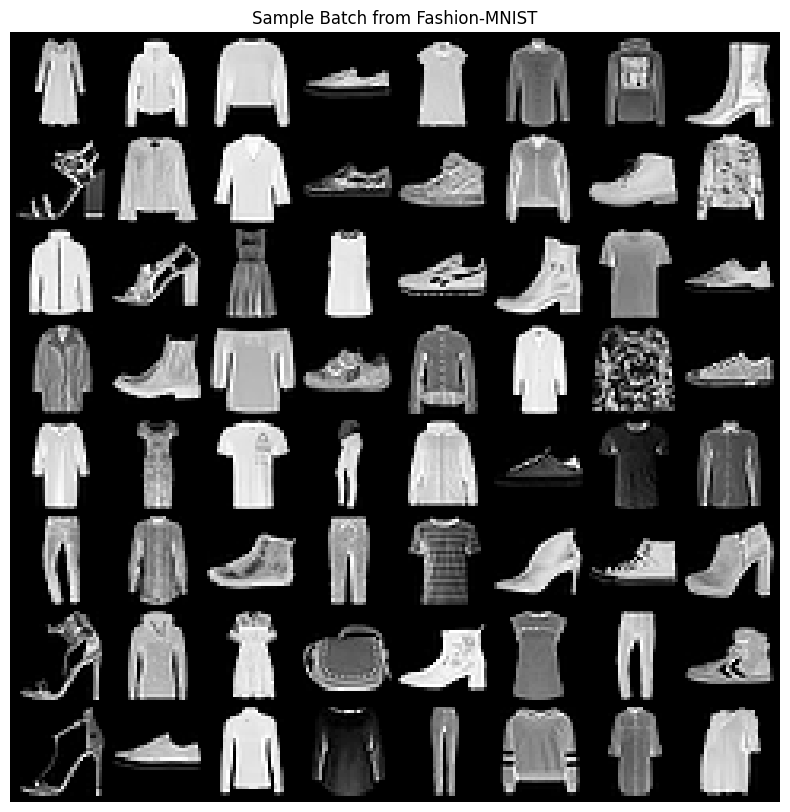

In [2]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Гиперпараметры данных
BATCH_SIZE = 128  

# Подготовка трансформаций
transform = transforms.Compose([
    transforms.ToTensor(), 
])

# Загрузка обучающего набора данных
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Создание DataLoader
# shuffle перемешивает данные каждую эпоху
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

print(f"Dataset loaded successfully.")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

# Визуализация
def show_batch(loader):
    images, labels = next(iter(loader))
    
    grid_img = torchvision.utils.make_grid(images[:64], nrow=8, padding=2)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.title("Sample Batch from Fashion-MNIST")
    plt.show()
    
show_batch(train_loader)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

INPUT_DIM = 784        # 28x28 пикселей
HIDDEN_DIM = 400       # Размер скрытого слоя 
LATENT_DIM = 20        # Размерность латентного пространства

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        
        # Предсказываем параметры распределения
        self.fc_mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)

        # Decoder
        self.fc3 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.fc4 = nn.Linear(HIDDEN_DIM, INPUT_DIM)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        """
        z = mu + std * epsilon
        Позволяет backpropagation работать через стохастический узел.
        """
        if self.training:
            # Вычисляем стандартное отклонение из логарифма дисперсии
            std = torch.exp(0.5 * logvar)
            # Генерируем случайный шум epsilon из стандартного нормального распределения
            eps = torch.randn_like(std)
            # Сдвигаем и масштабируем
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        """
        Возвращает: восстановленное изображение, mu, logvar
        """
        # Сглаживание (N, 1, 28, 28) -> (N, 784)
        x = x.view(-1, INPUT_DIM)
        
        # Encode
        mu, logvar = self.encode(x)
        
        # Sample latent vector
        z = self.reparameterize(mu, logvar)
        
        # Decode
        recon_x = self.decode(z)
        
        return recon_x, mu, logvar

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = VAE().to(device)

print("Architecture defined:")
print(model)

Architecture defined:
VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)


Starting training on mps for 20 epochs...
Epoch: 1 | Average Loss: 285.7304
Epoch: 2 | Average Loss: 257.0487
Epoch: 3 | Average Loss: 251.1205
Epoch: 4 | Average Loss: 248.0903
Epoch: 5 | Average Loss: 246.3117
Epoch: 6 | Average Loss: 245.1119
Epoch: 7 | Average Loss: 244.2623
Epoch: 8 | Average Loss: 243.7037
Epoch: 9 | Average Loss: 243.1704
Epoch: 10 | Average Loss: 242.7262
Epoch: 11 | Average Loss: 242.3794
Epoch: 12 | Average Loss: 242.0642
Epoch: 13 | Average Loss: 241.7683
Epoch: 14 | Average Loss: 241.5156
Epoch: 15 | Average Loss: 241.2720
Epoch: 16 | Average Loss: 241.1044
Epoch: 17 | Average Loss: 240.9062
Epoch: 18 | Average Loss: 240.7413
Epoch: 19 | Average Loss: 240.5813
Epoch: 20 | Average Loss: 240.4429

Training finished in 43.96 seconds.


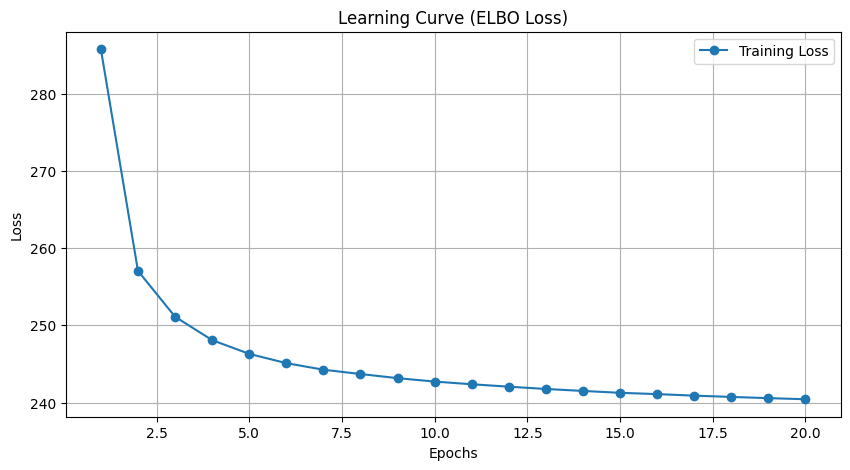

In [4]:
import torch.optim as optim
import time

# Определение функции потерь 
def loss_function(recon_x, x, mu, logvar):
    """
    recon_x: восстановленная картинка (batch_size, 784)
    x: исходная картинка (batch_size, 1, 28, 28)
    mu, logvar: параметры латентного распределения
    """
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Цикл обучения
EPOCHS = 20
LOG_INTERVAL = 5  

print(f"Starting training on {device} for {EPOCHS} epochs...")
start_time = time.time()

model.train() 

loss_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        # Обнуляем градиенты
        optimizer.zero_grad()
        
        # Прогон через модель
        recon_batch, mu, logvar = model(data) 
        
        # Вычисление потерь
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # Обратное распространение ошибки
        loss.backward()
        train_loss += loss.item()
        
        # Шаг оптимизатора
        optimizer.step()

    # Статистика за эпоху
    avg_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f'Epoch: {epoch} | Average Loss: {avg_loss:.4f}')

end_time = time.time()
print(f"\nTraining finished in {end_time - start_time:.2f} seconds.")

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', label='Training Loss')
plt.title('Learning Curve (ELBO Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

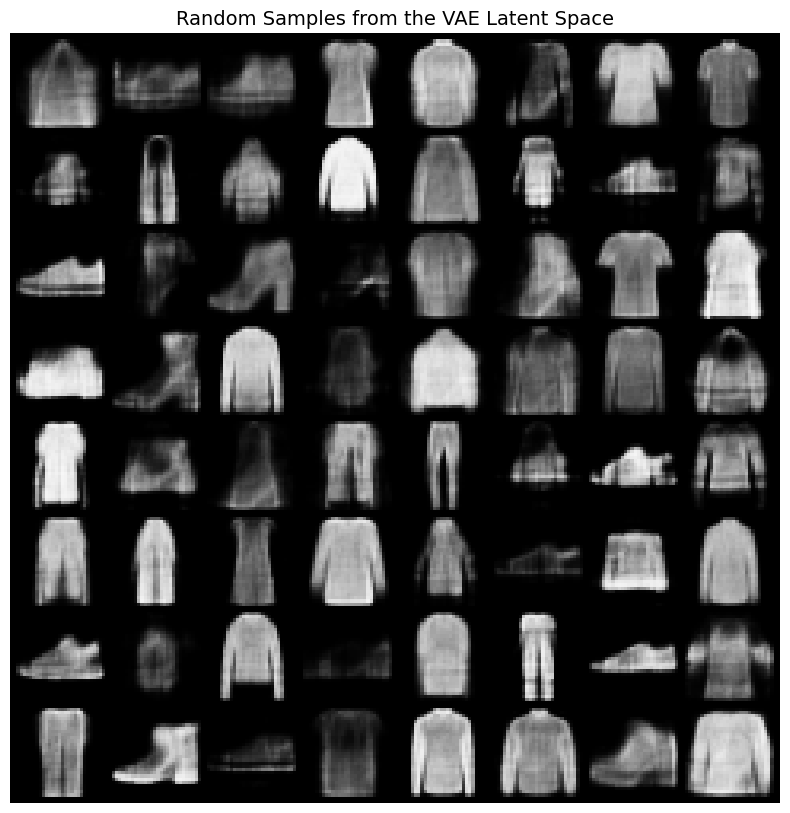

In [5]:
model.eval()

def generate_new_images(model, n_samples=64):
    """
    Генерирует новые изображения из случайного шума (латентного пространства).
    """
    with torch.no_grad():
        # Сэмплируем случайный вектор из нормального распределения
        z = torch.randn(n_samples, LATENT_DIM).to(device)
        
        # Прогоняем через декодер
        generated_images = model.decode(z).cpu()
        
        # Возвращаем форму картинки (64, 1, 28, 28)
        return generated_images.view(-1, 1, 28, 28)

# Генерируем
generated_data = generate_new_images(model)

# Визуализация 
plt.figure(figsize=(10, 10))
plt.title(r"Random Samples from the VAE Latent Space", fontsize=14)
grid_img = torchvision.utils.make_grid(generated_data, nrow=8, padding=2, normalize=False)
plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
plt.axis('off')
plt.show()

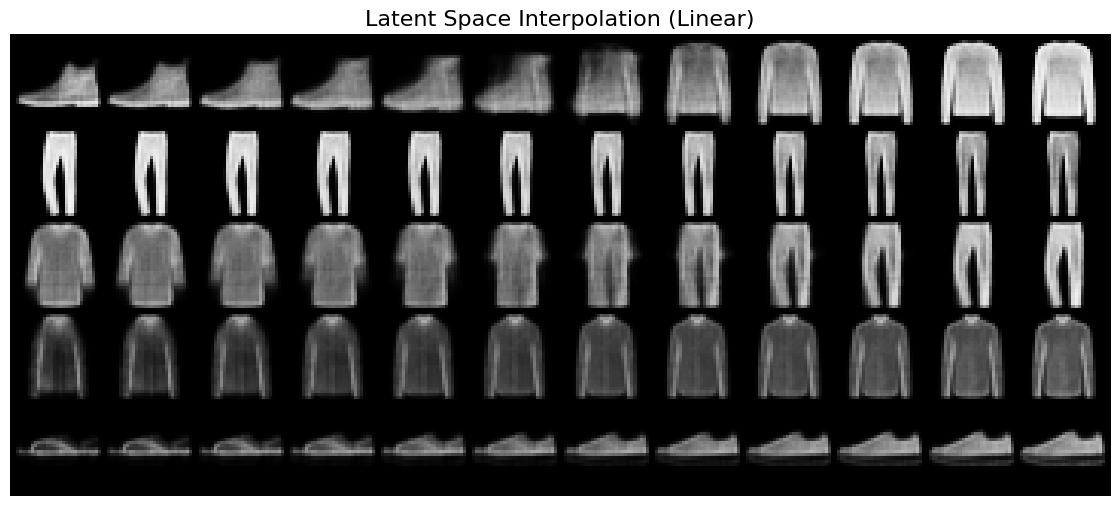

In [6]:
def interpolate_points(p1, p2, n_steps=10):
    """
    Линейная интерполяция между двумя векторами p1 и p2.
    Возвращает список векторов (тензоров).
    """
    # Список значений
    ratios = np.linspace(0, 1, num=n_steps)
    vectors = []
    for ratio in ratios:
        # Формула линейной интерполяции: (1-a)*v1 + a*v2
        v = (1.0 - ratio) * p1 + ratio * p2
        vectors.append(v)
    return torch.stack(vectors)

def visualize_interpolation(model, loader, device, num_pairs=3):
    model.eval()
    
    # Берем один батч из тестовой выборки 
    data_iter = iter(loader)
    images, _ = next(data_iter)
    images = images.to(device)
    
    # Кодируем изображения, чтобы получить их центры распределений (mu)
    with torch.no_grad():
        mu, _ = model.encode(images.view(-1, 784))
    
    # Настройка визуализации
    plt.figure(figsize=(15, 6))
    plt.title("Latent Space Interpolation (Linear)", fontsize=16)
    plt.axis('off')
    
    # Для отрисовки
    rows = num_pairs
    cols = 12 
    
    # Пары изображений 
    final_grid = []
    
    for i in range(num_pairs):
        idx1, idx2 = i * 2, i * 2 + 1
        
        vec1 = mu[idx1] # Вектор первого изображения
        vec2 = mu[idx2] # Вектор второго изображения
        
        # Получаем 12 промежуточных векторов
        interp_vectors = interpolate_points(vec1, vec2, n_steps=12)
        
        # Декодируем их обратно в картинки
        with torch.no_grad():
            generated = model.decode(interp_vectors).cpu()
            generated = generated.view(-1, 1, 28, 28)
        
        final_grid.append(generated)
    
    # Объединяем все в один большой тензор
    final_tensor = torch.cat(final_grid, dim=0)
    
    grid_img = torchvision.utils.make_grid(final_tensor, nrow=12, padding=2, normalize=False)
    
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.axis('off')
    plt.show()

visualize_interpolation(model, test_loader, device, num_pairs=5)